In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted!")

Mounted at /content/drive
✓ Google Drive mounted!


In [8]:
# ============================================================
# STUDENT PERFORMANCE DATA CLEANING & PREPROCESSING
# ============================================================

# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr

# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

student_data = pd.read_csv("/content/drive/MyDrive/ML/Untitled folder/StudentsPerformance.csv")

# Preview Dataset
student_data.head()

# ============================================================
# STEP 3: BASIC DATA INSPECTION
# ============================================================

# Dataset Shape
print(student_data.shape)

# Column Names
print(student_data.columns)

# Dataset Information
student_data.info()

# Statistical Summary
student_data.describe()

(1000, 8)
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
# ============================================================
# STEP 4: CHECK MISSING VALUES
# ============================================================

print(student_data.isnull().sum())



gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [13]:
# ============================================================
# STEP 5: CHECK DUPLICATES
# ============================================================

# Full Row Duplicate Check
print(student_data.duplicated().sum())

# View Duplicate Rows
print(student_data[student_data.duplicated()])


0
Empty DataFrame
Columns: [gender, race/ethnicity, parental level of education, lunch, test preparation course, math score, reading score, writing score]
Index: []


In [18]:
# Create Average Score
student_data["average_score"] = (
    student_data["math score"] +
    student_data["reading score"] +
    student_data["writing score"]
) / 3

# Define conditions
conditions = [
    (student_data["average_score"] >= 80),
    (student_data["average_score"] >= 60) & (student_data["average_score"] < 80),
    (student_data["average_score"] < 60)
]

choices = ["Excellent", "Average", "Poor"]

# FIX: force object dtype (IMPORTANT)
student_data["performance"] = np.select(
    conditions,
    choices,
    default="Poor"
).astype(object)

# Check
student_data[["average_score", "performance"]].head()

,average_score,performance
0,72.666667,Average
1,82.333333,Excellent
2,92.666667,Excellent
3,49.333333,Poor
4,76.333333,Average


In [19]:
# ============================================================
# STEP 7: LABEL ENCODING TARGET VARIABLE
# ============================================================

# Encode Performance Column
performance_mapping = {
    "Poor": 0,
    "Average": 1,
    "Excellent": 2
}

student_data["performance"] = (
    student_data["performance"]
    .map(performance_mapping)
)

# ============================================================
# STEP 8: ONE-HOT ENCODING NOMINAL VARIABLES
# ============================================================

student_data = pd.get_dummies(
    student_data,
    columns=[
        "gender",
        "race/ethnicity",
        "lunch",
        "test preparation course"
    ],
    drop_first=True
)

# ============================================================
# STEP 9: LABEL ENCODING ORDINAL VARIABLE
# ============================================================

education_order = {
    "some high school": 0,
    "high school": 1,
    "some college": 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}

student_data["parental level of education"] = (
    student_data["parental level of education"]
    .map(education_order)
)



In [20]:
# ============================================================
# STEP 10: DROP LEAKAGE VARIABLES
# ============================================================

# # These variables were used to create target variable
student_data = student_data.drop(
    columns=[
        "math score",
        "reading score",
        "writing score",
        "average_score"
    ]
)

# ============================================================
# STEP 11: CHECK FINAL DATASET
# ============================================================

student_data.head()

student_data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   parental level of education   1000 non-null   int64
 1   performance                   1000 non-null   int64
 2   gender_male                   1000 non-null   bool 
 3   race/ethnicity_group B        1000 non-null   bool 
 4   race/ethnicity_group C        1000 non-null   bool 
 5   race/ethnicity_group D        1000 non-null   bool 
 6   race/ethnicity_group E        1000 non-null   bool 
 7   lunch_standard                1000 non-null   bool 
 8   test preparation course_none  1000 non-null   bool 
dtypes: bool(7), int64(2)
memory usage: 22.6 KB


/tmp/ipykernel_9871/3063160142.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Poor", "Average", "Excellent"])


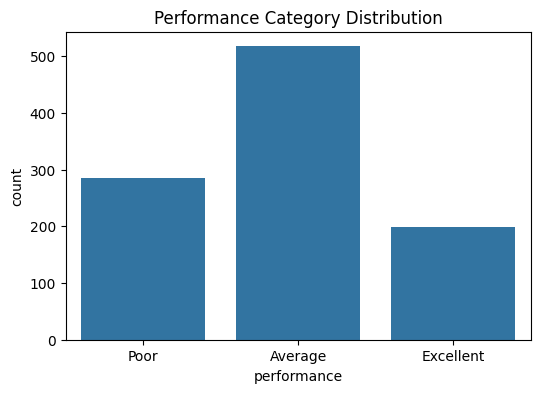

In [22]:
# ============================================================
# STEP 12: TARGET VARIABLE DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,4))

ax = sns.countplot(x=student_data["performance"])

plt.title("Performance Category Distribution")

# labels
ax.set_xticklabels(["Poor", "Average", "Excellent"])

plt.show()

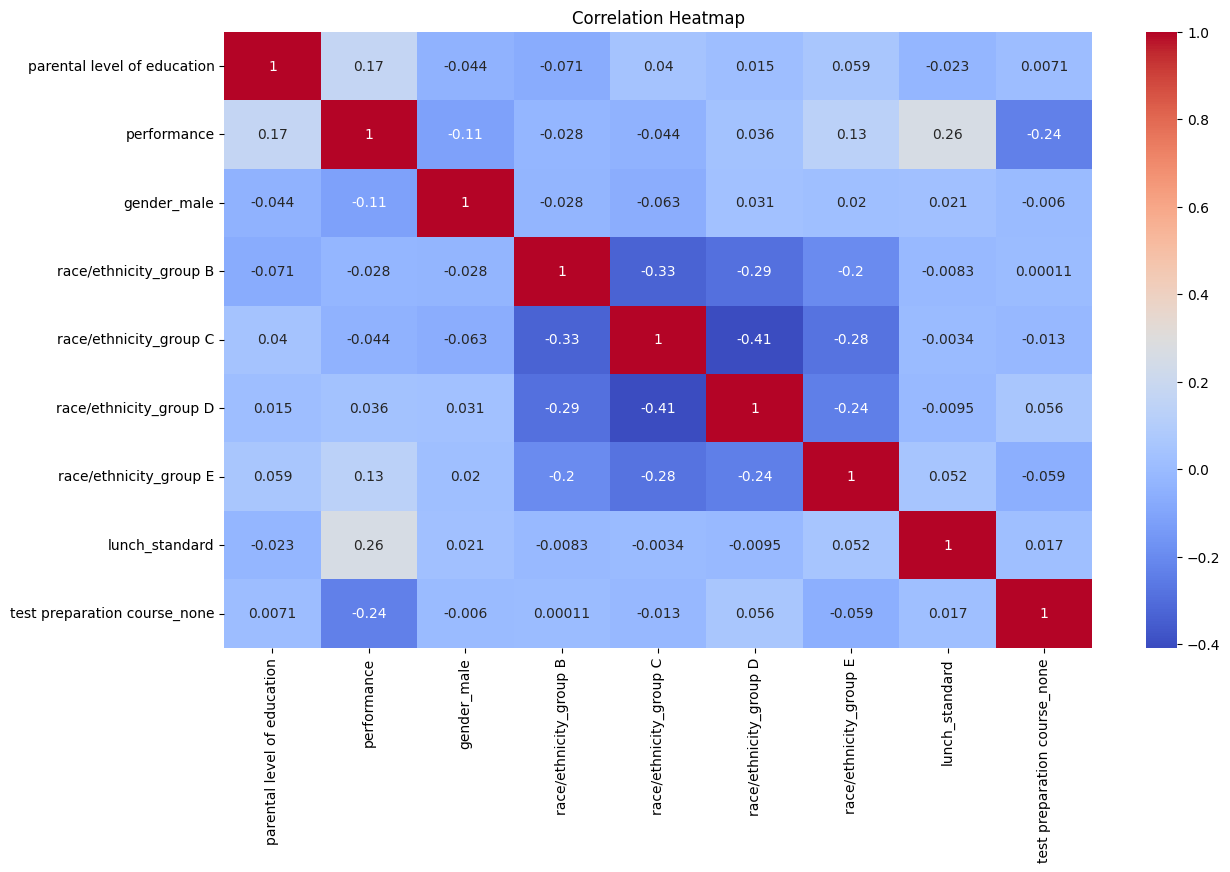

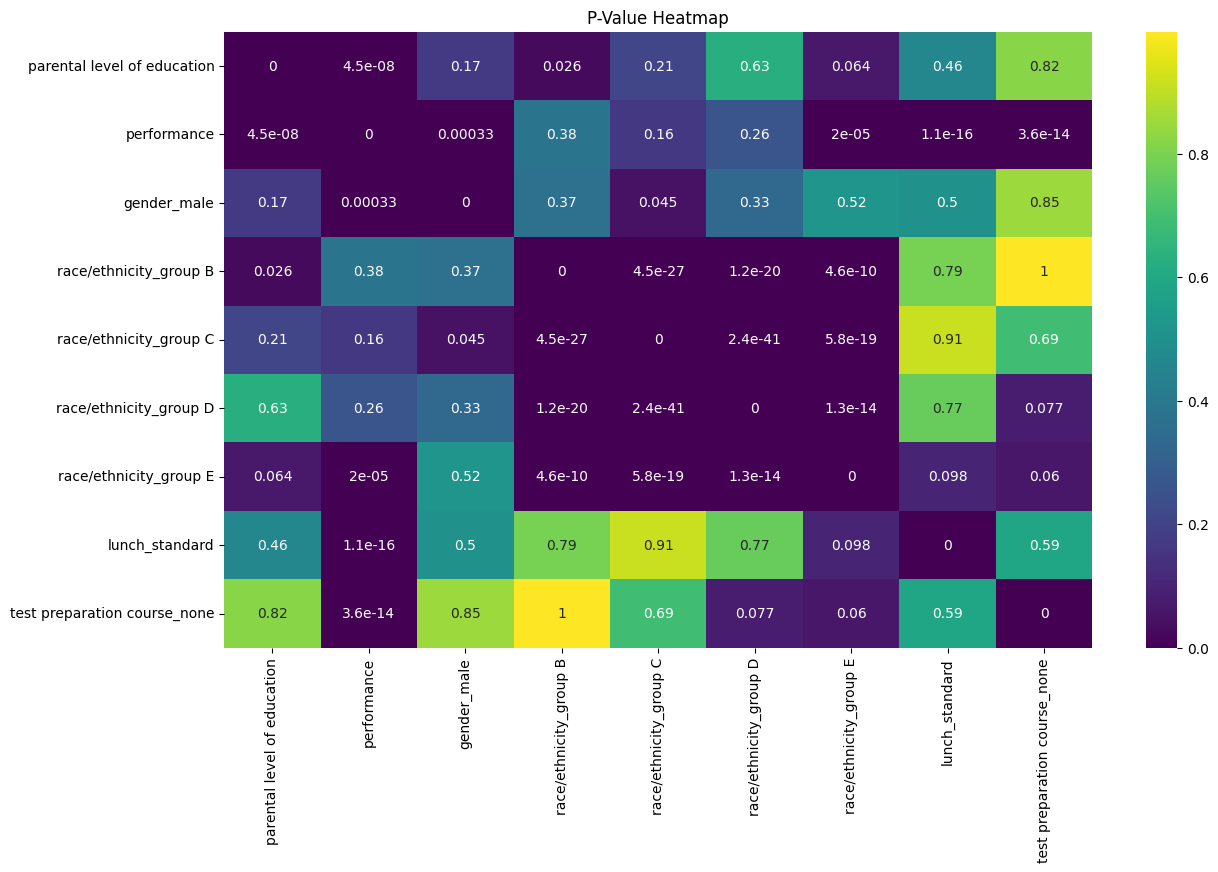

,Correlation,P-Value
performance,1.000000,0.000000e+00
lunch_standard,0.257969,1.149875e-16
parental level of education,0.171944,4.466768e-08
race/ethnicity_group E,0.134502,1.977514e-05
race/ethnicity_group D,0.035601,2.606972e-01
race/ethnicity_group B,-0.027616,3.830108e-01
race/ethnicity_group C,-0.044331,1.612694e-01
gender_male,-0.113388,3.272081e-04
test preparation course_none,-0.236404,3.619181e-14


In [23]:
# ============================================================
# STEP 13: CORRELATION MATRIX
# ============================================================

corr_matrix = student_data.corr()

corr_matrix

# ============================================================
# STEP 14: P-VALUE MATRIX
# ============================================================

# Create Empty DataFrame
p_values = pd.DataFrame(
    np.ones_like(corr_matrix),
    columns=corr_matrix.columns,
    index=corr_matrix.index
)

# Calculate P-Values
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:

        if col1 == col2:
            p_values.loc[col1, col2] = 0

        else:
            _, p = pearsonr(
                student_data[col1],
                student_data[col2]
            )

            p_values.loc[col1, col2] = p

p_values

# ============================================================
# STEP 15: CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(14,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

# ============================================================
# STEP 16: P-VALUE HEATMAP
# ============================================================

plt.figure(figsize=(14,8))

sns.heatmap(
    p_values,
    cmap="viridis",
    annot=True
)

plt.title("P-Value Heatmap")

plt.show()

# ============================================================
# STEP 17: TARGET CORRELATION ANALYSIS
# ============================================================

# Correlation with Target
target_corr = corr_matrix["performance"].sort_values(
    ascending=False
)

# P-Values with Target
target_pvals = p_values["performance"]

# Combined Results
result = pd.DataFrame({
    "Correlation": target_corr,
    "P-Value": target_pvals
})

result.sort_values(
    by="Correlation",
    ascending=False
)

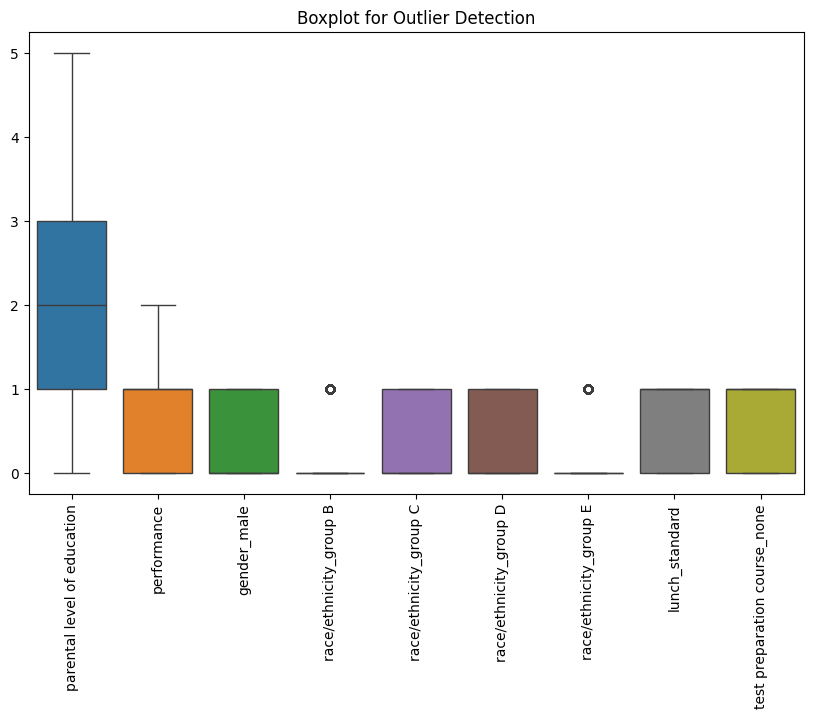

In [24]:
# ============================================================
# STEP 18: OUTLIER DETECTION
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(data=student_data)

plt.title("Boxplot for Outlier Detection")

plt.xticks(rotation=90)

plt.show()

In [25]:
# ============================================================
# STEP 19: CLASS BALANCE CHECK
# ============================================================

student_data["performance"].value_counts()

# Percentage Distribution
student_data["performance"].value_counts(normalize=True) * 100

,proportion
performance,
1,51.7
0,28.5
2,19.8


In [26]:
# ============================================================
# STEP 20: SAVE CLEANED DATASET
# ============================================================

student_data.to_csv(
    "student_performance_cleaned.csv",
    index=False
)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully
